# Customer Segmentation using K-Means Clustering

## 1. Import Libraries

The required libraries for data manipulation, visualization, clustering, and dimensionality reduction were imported.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Observation

All the required libraries were successfully imported. These libraries will be used for data preprocessing, visualization, clustering, feature scaling, and dimensionality reduction.

## 2. Load Dataset

The Mall Customer dataset was loaded into a Pandas DataFrame.

In [3]:
df = pd.read_csv("../data/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Observation

The dataset was loaded successfully, and the first five records were displayed to verify the data.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


### Observation

The dataset contains **200 customer records** and **5 features**. All columns have complete data with no missing values. The dataset includes one categorical feature (`Gender`) and four numerical features, making it suitable for customer segmentation using K-Means clustering.

In [5]:
df.shape

(200, 5)

In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Observation

- The dataset contains **200 customers** and **5 features**.
- No missing values were found in the dataset.
- Customer ages range from **18 to 70 years**.
- Annual income ranges from **15k to 137k**.
- Spending scores range from **1 to 99**.
- The dataset is clean and ready for clustering.

## 7. Remove Unnecessary Feature

The `CustomerID` column was removed because it is a unique identifier and does not contribute to customer segmentation.

In [8]:
df.drop(columns=["CustomerID"], inplace=True)

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


## 8. Encode Categorical Feature

The `Gender` column was converted into numerical values using Label Encoding.

In [9]:
from sklearn.preprocessing import LabelEncoder

gender_encoder = LabelEncoder()

df["Gender"] = gender_encoder.fit_transform(df["Gender"])

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [10]:
original_df = pd.read_csv("../data/Mall_Customers.csv")

encoder = LabelEncoder()

encoder.fit(original_df["Gender"])

print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

{'Female': np.int64(0), 'Male': np.int64(1)}


### Observation

The `Gender` feature was encoded using Label Encoding.

- Female = 0
- Male = 1

This conversion makes the categorical feature suitable for K-Means clustering.

## 9. Feature Selection

The features required for customer segmentation were selected.

For clustering, only the following customer-related attributes were used:

- Age
- Annual Income (k$)
- Spending Score (1–100)

The `Gender` column was excluded from clustering to focus on customer behavior rather than demographic information.

In [11]:
features = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

features.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


## 10. Feature Scaling

The selected features were standardized using **StandardScaler** before applying K-Means clustering.

Feature scaling ensures that all features contribute equally to the distance calculations.

In [12]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

## 11. Exploratory Data Analysis

Exploratory Data Analysis (EDA) was performed to understand the distribution of customer features before applying K-Means clustering.

### Age Distribution

The distribution of customer ages was visualized using a histogram.

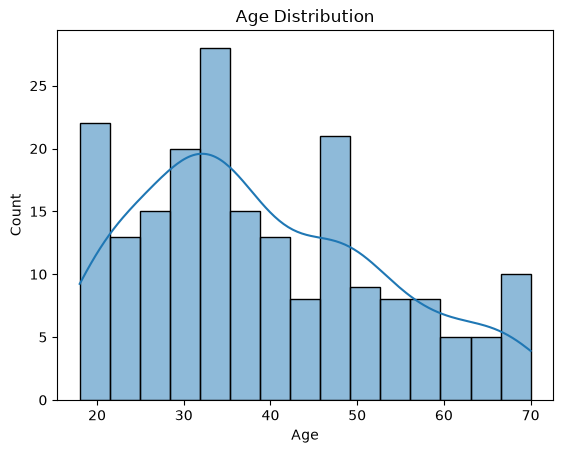

In [13]:
sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True
)

plt.title("Age Distribution")
plt.show()

### Observation

The histogram shows that most customers belong to the **25–40 years** age group. Fewer customers are above **60 years** of age. The age values are well distributed between **18 and 70 years**, making Age an important feature for customer segmentation.

### Annual Income Distribution

The distribution of customer annual income was visualized using a histogram.

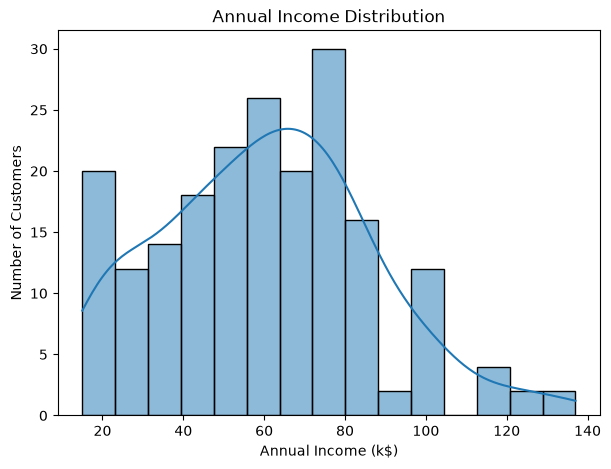

In [14]:
plt.figure(figsize=(7,5))

sns.histplot(
    data=df,
    x="Annual Income (k$)",
    bins=15,
    kde=True
)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The annual income ranges from **15k to 137k**. Most customers have an annual income between **50k and 80k**, while only a few customers belong to the very high-income group (above 100k). This variation in income makes it an important feature for customer segmentation.

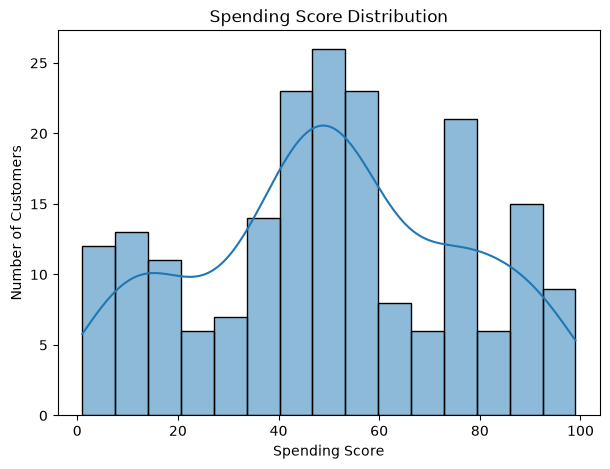

In [16]:
plt.figure(figsize=(7,5))

sns.histplot(
    data=df,
    x="Spending Score (1-100)",
    bins=15,
    kde=True
)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The spending scores range from **1 to 99**, indicating that the dataset contains both low-spending and high-spending customers. Most customers have spending scores between **40 and 60**, while fewer customers belong to the extreme low or high spending groups. This variation makes Spending Score an important feature for customer segmentation.

### Correlation Heatmap

A correlation heatmap was generated to examine the relationships between numerical features.

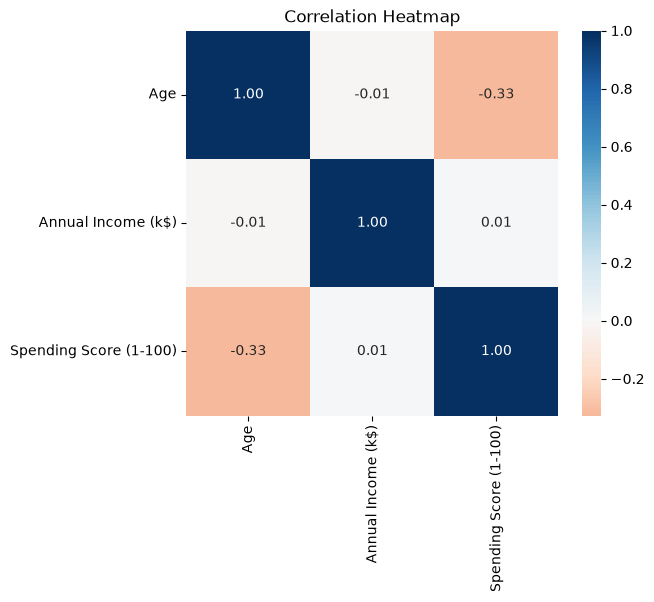

In [20]:
plt.figure(figsize=(6,5))

sns.heatmap(
    features.corr(),
    annot=True,
    cmap="RdBu",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The correlation heatmap shows the relationship among the selected features:

- **Age and Annual Income** have almost **no correlation (-0.01)**, indicating that a customer's age does not significantly influence their annual income.
- **Annual Income and Spending Score** also have **almost no correlation (0.01)**, suggesting that customers with higher income do not necessarily spend more.
- **Age and Spending Score** have a **weak negative correlation (-0.33)**, indicating that spending tends to decrease slightly as age increases.

Overall, the selected features are **not strongly correlated**, meaning each feature contributes unique information. This makes them suitable for **K-Means clustering**, as the algorithm can use all three features to identify meaningful customer segments.

## 12. Elbow Method

The Elbow Method was used to determine the optimal number of clusters for K-Means clustering.

In [21]:
wcss = []

for i in range(1, 11):
    
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_features)
    
    wcss.append(kmeans.inertia_)

## 13. Elbow Curve

The Elbow Curve was plotted using the WCSS values calculated for different numbers of clusters. The optimal number of clusters is identified at the point where the decrease in WCSS starts to slow down.

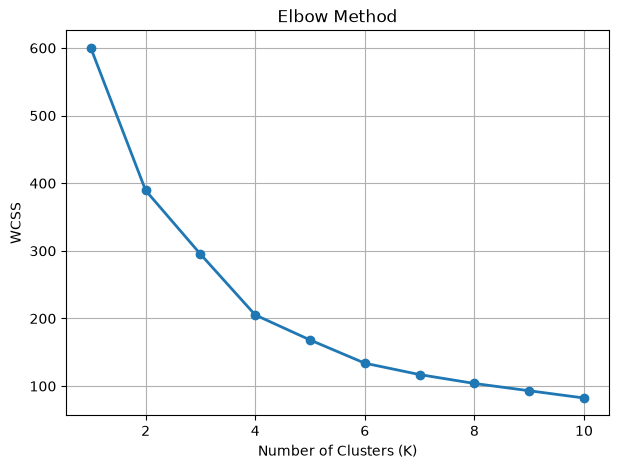

In [22]:
plt.figure(figsize=(7,5))

plt.plot(
    range(1, 11),
    wcss,
    marker="o",
    linewidth=2
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

### Observation

The Elbow Curve shows a sharp decrease in WCSS from **K = 1** to **K = 5**. After **K = 5**, the reduction in WCSS becomes much smaller, indicating diminishing returns from adding more clusters. Therefore, the optimal number of clusters selected for K-Means clustering is **5**.

## 14. Apply K-Means Clustering

Based on the Elbow Method, the optimal number of clusters was selected as **5**.

The K-Means algorithm was applied to group customers into five distinct clusters.

In [23]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_features)

df["Cluster"] = clusters

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,1
1,1,21,15,81,1
2,0,20,16,6,0
3,0,23,16,77,1
4,0,31,17,40,1


In [24]:
df["Cluster"].value_counts()

Cluster
1    54
4    47
2    40
3    39
0    20
Name: count, dtype: int64

In [25]:
df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


### Observation

The cluster-wise averages show that each cluster represents a distinct customer segment.

- Cluster 0: Low Income, Low Spending customers.
- Cluster 1: Young customers with medium income and high spending.
- Cluster 2: High Income, High Spending customers (VIP customers).
- Cluster 3: High Income but Low Spending customers (potential customers).
- Cluster 4: Older customers with medium income and moderate spending.

These distinct patterns indicate that the K-Means algorithm successfully segmented customers based on their purchasing behavior.

## 15. Customer Cluster Visualization

The customer clusters were visualized using a scatter plot based on **Annual Income** and **Spending Score**.

Each color represents a different customer segment identified by the K-Means algorithm.

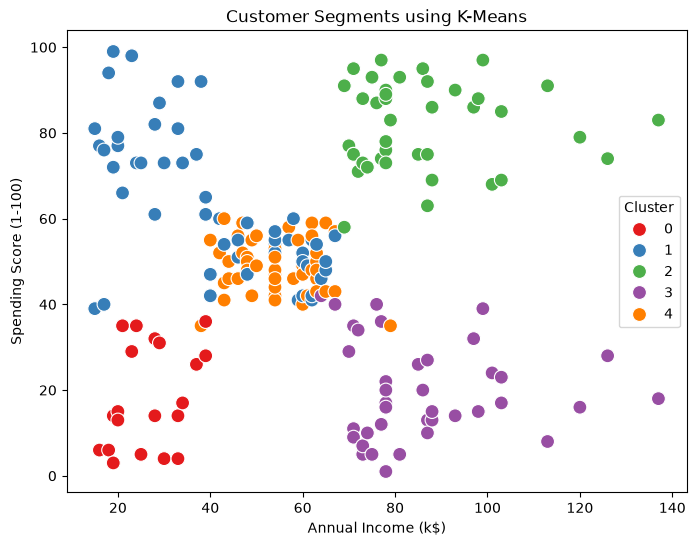

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("Customer Segments using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.legend(title="Cluster")

plt.show()

### Cluster 0

Customers in this cluster have **low annual income and low spending scores**. They represent budget-conscious customers with limited purchasing power.

### Cluster 1

Customers in this cluster have **low income but high spending scores**. They are likely enthusiastic shoppers despite having limited income.

### Cluster 2

Customers in this cluster have **high income and high spending scores**. They are the most valuable customers and should be targeted with premium services and loyalty programs.

### Cluster 3

Customers in this cluster have **high income but low spending scores**. These customers have strong purchasing power but spend less, making them ideal targets for promotional campaigns.

### Cluster 4

Customers in this cluster have **moderate income and moderate spending scores**. They represent average customers who can be retained through regular promotional offers.

## 16. Principal Component Analysis (PCA)

Principal Component Analysis (PCA) was applied to reduce the three-dimensional feature space into two principal components for visualization.

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(
    pca_features,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,-0.615720,-1.763481,1
1,-1.665793,-1.820747,1
2,0.337862,-1.674799,0
3,-1.456573,-1.772430,1
4,-0.038465,-1.662740,1


## 17. PCA Visualization

The customer clusters were visualized using the two principal components generated by PCA.

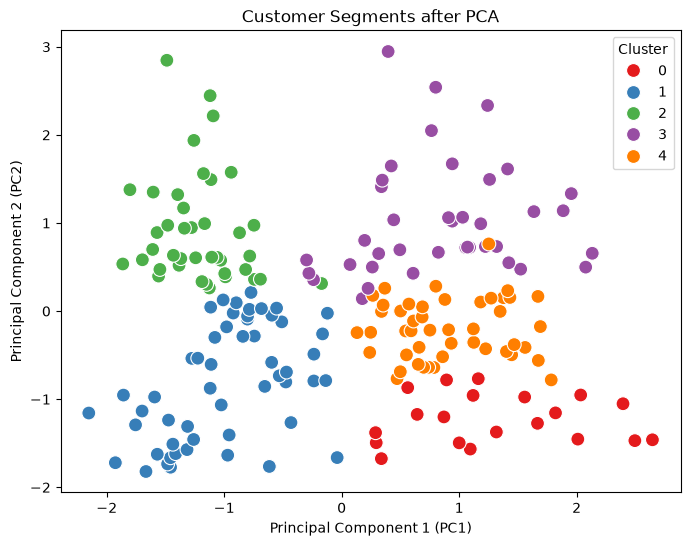

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("Customer Segments after PCA")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")

plt.legend(title="Cluster")

plt.show()

### Observation

The PCA visualization shows that the five customer clusters remain clearly distinguishable even after reducing the data from three dimensions to two principal components. This indicates that PCA preserved most of the important information while making the clustered data easier to visualize and interpret.

# Business Insights

### Cluster 0 – Low Income, Low Spending Customers

This customer segment has the **lowest average annual income** and also records the **lowest spending score**. These customers appear to be highly price-conscious and generally make limited purchases.

Instead of investing heavily in premium marketing campaigns, the business should focus on affordable product bundles, seasonal discounts, cashback offers, and value-for-money promotions. Such strategies are more likely to encourage purchases from this segment without increasing marketing costs unnecessarily.

**Business Impact:**  
A budget-focused strategy can improve conversion rates among price-sensitive customers while maintaining efficient marketing expenditure.

### Cluster 1 – Young Customers with Active Spending Behavior

Customers in this cluster are relatively young and exhibit a higher spending score despite having only moderate income levels. This indicates strong purchasing interest and high engagement with shopping activities.

This segment is likely to respond well to digital marketing campaigns, social media advertisements, referral programs, and limited-time promotional offers. Since these customers are already active buyers, maintaining regular engagement can increase their purchase frequency.

**Business Impact:**  
Strengthening customer engagement for this segment can improve customer lifetime value and encourage repeat purchases.

### Cluster 2 – High Income, High Spending Customers

This cluster represents the most valuable customers in the dataset. They have both **high purchasing power** and a **high willingness to spend**, making them the primary revenue-generating customer segment.

The business should prioritize retaining these customers by offering VIP memberships, exclusive product launches, personalized recommendations, premium customer support, and loyalty rewards.

Acquiring a new customer is often more expensive than retaining an existing valuable customer. Therefore, maintaining satisfaction within this segment should be a strategic priority.

**Business Impact:**  
Retaining premium customers can significantly increase long-term revenue and strengthen brand loyalty.

### Cluster 3 – High Income but Low Spending Customers

This cluster presents one of the most valuable business opportunities. Although these customers have high annual income, their spending score remains comparatively low. This suggests that purchasing power is not the issue; rather, the current products, offers, or customer engagement strategies may not be effectively motivating purchases.

Instead of providing general discounts, the business should analyze customer preferences, purchase history, and browsing behavior to deliver personalized product recommendations and targeted promotional campaigns.

Converting even a small percentage of these customers into active buyers could generate a substantial increase in revenue because they already possess the financial capacity to spend more.

**Business Impact:**  
This segment offers the highest growth potential and should be considered a priority for personalized marketing strategies.

### Cluster 4 – Moderate Income, Moderate Spending Customers

Customers in this cluster demonstrate stable purchasing behavior with moderate income and average spending levels. They represent a consistent customer base that contributes regular sales throughout the year.

Rather than focusing on aggressive promotional campaigns, the business should strengthen customer relationships through loyalty programs, seasonal offers, family-oriented promotions, and personalized communication to maintain long-term engagement.

**Business Impact:**  
Improving customer retention within this segment helps generate stable and predictable revenue while reducing customer acquisition costs.

## Final Business Conclusion

The customer segmentation clearly shows that **every customer has different shopping behavior**, so treating everyone with the same marketing strategy would not be effective.

The analysis highlights that **High Income–High Spending customers** are the most valuable customers for the business. Retaining them through loyalty programs, exclusive offers, and premium services can generate consistent long-term revenue.

Another interesting finding is the **High Income–Low Spending** segment. These customers have the ability to spend but currently purchase less. This makes them a high-potential segment, where personalized recommendations and targeted campaigns can significantly increase sales.

The **Young, Active Shoppers** segment already spends well despite having moderate income. Regular engagement through social media campaigns, referral programs, and limited-time offers can further strengthen their loyalty.

For **Price-Sensitive customers**, affordability is more important than premium products. Budget-friendly offers and seasonal discounts are likely to perform better than expensive marketing campaigns.

Overall, this customer segmentation enables the business to understand customer behavior more effectively and design personalized marketing strategies instead of following a one-size-fits-all approach. This not only improves customer satisfaction but also helps increase marketing efficiency, customer retention, and overall business growth.

> **Instead of spending more on marketing, the business should focus on spending smarter by delivering the right offer to the right customer at the right time. This customer-centric approach improves marketing efficiency, strengthens customer relationships, and drives sustainable business growth.**